# 04 — Transfer learning

La pregunta del notebook es directa: dadas dos arquitecturas pre-entrenadas en ImageNet y dos estrategias de uso, ¿cuál combinación nos da el mejor clasificador? Probamos las cuatro variantes que tienen sentido:

|   | ResNet18 | EfficientNet-B0 |
|---|---|---|
| **Feature extraction** (backbone congelado, sólo se entrena la cabeza) | rápido, suelo bajo | rápido, suelo bajo |
| **Fine-tuning** (todos los pesos aprendibles, LR diferencial) | más caro pero techo alto | más caro, techo alto |

En la cabeza final usamos para todas las variantes la misma capa: `Linear(in_features → 256) → ReLU → Dropout(0.3) → Linear(256 → 196 clases)`. En el fine-tuning aplicamos un LR diferencial: 1e-5 para el backbone (cambios suaves sobre los pesos pre-entrenados) y 1e-3 para la cabeza (que parte de aleatorio y necesita aprender deprisa). Entrenamos cada configuración 10 épocas con batch 128 y mixed precision en GPU.

El modelo ganador se serializa en `saved_models/best_model.pt` junto con `best_model_config.json`, que es lo que cargará el notebook 06 para la demo interactiva.

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import torch, numpy as np, random
torch.manual_seed(42); np.random.seed(42); random.seed(42)
torch.backends.cudnn.benchmark = True

METADATA_PATH = ROOT / 'data' / 'metadata.csv'
MODELS_DIR    = ROOT / 'saved_models'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

from src import (PretrainedModel, get_dataloaders, train_model,
                 plot_training_curves, full_evaluation_report,
                 plot_confusion_matrix, plot_per_class_f1, plot_roc_curves)

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
EPOCHS = 10
BATCH = 128 if DEVICE == 'cuda' else 32
NUM_WORKERS = 4 if DEVICE == 'cuda' else 0

train_loader, val_loader, test_loader, class_names, class_to_idx = get_dataloaders(
    metadata_path=str(METADATA_PATH), batch_size=BATCH, num_workers=NUM_WORKERS, root_dir=ROOT,
)
NUM_CLASSES = len(class_names)
print(f'NUM_CLASSES = {NUM_CLASSES}')
print(f'Train batches: {len(train_loader)}  Val: {len(val_loader)}  Test: {len(test_loader)}')

NUM_CLASSES = 196
Train batches: 322  Val: 69  Test: 69



=== resnet18_feature_extraction ===


[resnet18_feature_extraction] Epoch   1/10 | train_loss=2.9865 train_acc=0.2771 | val_loss=1.5321 val_acc=0.5917 | 138.4s


[resnet18_feature_extraction] Epoch   2/10 | train_loss=1.5332 train_acc=0.5297 | val_loss=1.0502 val_acc=0.6952 | 83.2s


[resnet18_feature_extraction] Epoch   3/10 | train_loss=1.2120 train_acc=0.6078 | val_loss=0.8489 val_acc=0.7490 | 93.9s


[resnet18_feature_extraction] Epoch   4/10 | train_loss=1.0650 train_acc=0.6466 | val_loss=0.7729 val_acc=0.7529 | 94.9s


...

[resnet18_feature_extraction] Epoch   6/10 | train_loss=0.9140 train_acc=0.6926 | val_loss=0.6361 val_acc=0.8048 | 98.5s


[resnet18_feature_extraction] Epoch   7/10 | train_loss=0.8643 train_acc=0.7085 | val_loss=0.6033 val_acc=0.8171 | 100.8s


[resnet18_feature_extraction] Epoch   8/10 | train_loss=0.8321 train_acc=0.7184 | val_loss=0.5983 val_acc=0.8176 | 95.3s


[resnet18_feature_extraction] Epoch   9/10 | train_loss=0.8280 train_acc=0.7211 | val_loss=0.5895 val_acc=0.8230 | 99.2s


[resnet18_feature_extraction] Epoch  10/10 | train_loss=0.8142 train_acc=0.7249 | val_loss=0.5698 val_acc=0.8273 | 95.9s


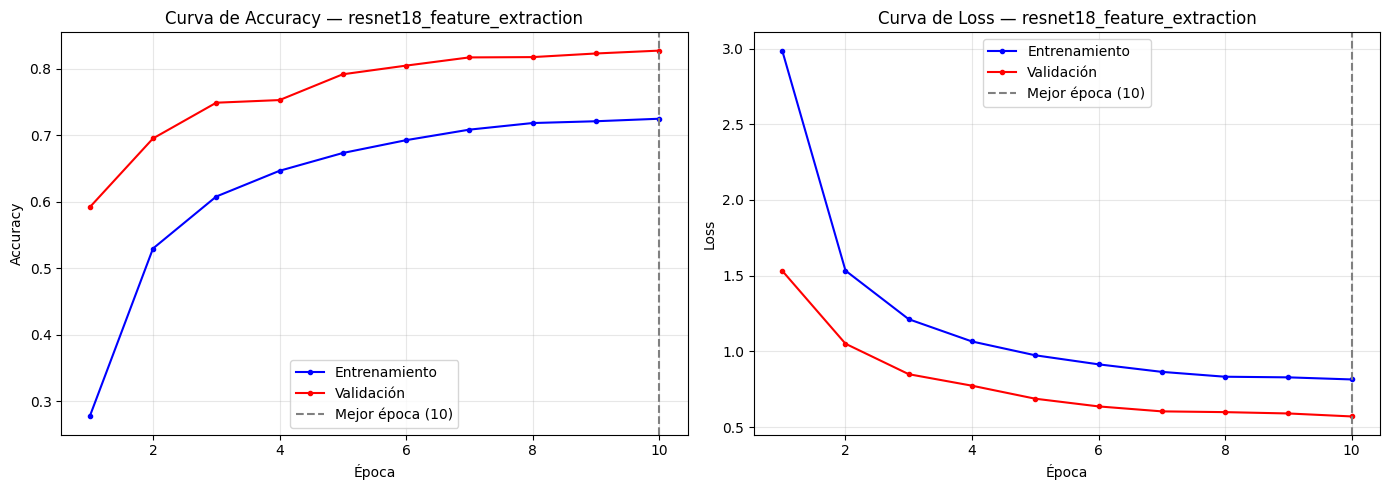


=== resnet18_finetune ===


[resnet18_finetune] Epoch   1/10 | train_loss=2.0038 train_acc=0.4947 | val_loss=0.2559 val_acc=0.9401 | 132.6s


[resnet18_finetune] Epoch   2/10 | train_loss=0.2757 train_acc=0.9126 | val_loss=0.0654 val_acc=0.9819 | 130.9s


[resnet18_finetune] Epoch   3/10 | train_loss=0.1283 train_acc=0.9599 | val_loss=0.0328 val_acc=0.9884 | 131.8s


[resnet18_finetune] Epoch   4/10 | train_loss=0.0842 train_acc=0.9729 | val_loss=0.0219 val_acc=0.9917 | 134.5s


...

[resnet18_finetune] Epoch   6/10 | train_loss=0.0572 train_acc=0.9806 | val_loss=0.0161 val_acc=0.9923 | 134.5s


[resnet18_finetune] Epoch   7/10 | train_loss=0.0472 train_acc=0.9834 | val_loss=0.0136 val_acc=0.9938 | 133.5s


[resnet18_finetune] Epoch   8/10 | train_loss=0.0393 train_acc=0.9863 | val_loss=0.0134 val_acc=0.9934 | 132.1s


[resnet18_finetune] Epoch   9/10 | train_loss=0.0399 train_acc=0.9861 | val_loss=0.0120 val_acc=0.9934 | 139.1s


[resnet18_finetune] Epoch  10/10 | train_loss=0.0368 train_acc=0.9867 | val_loss=0.0117 val_acc=0.9942 | 132.3s


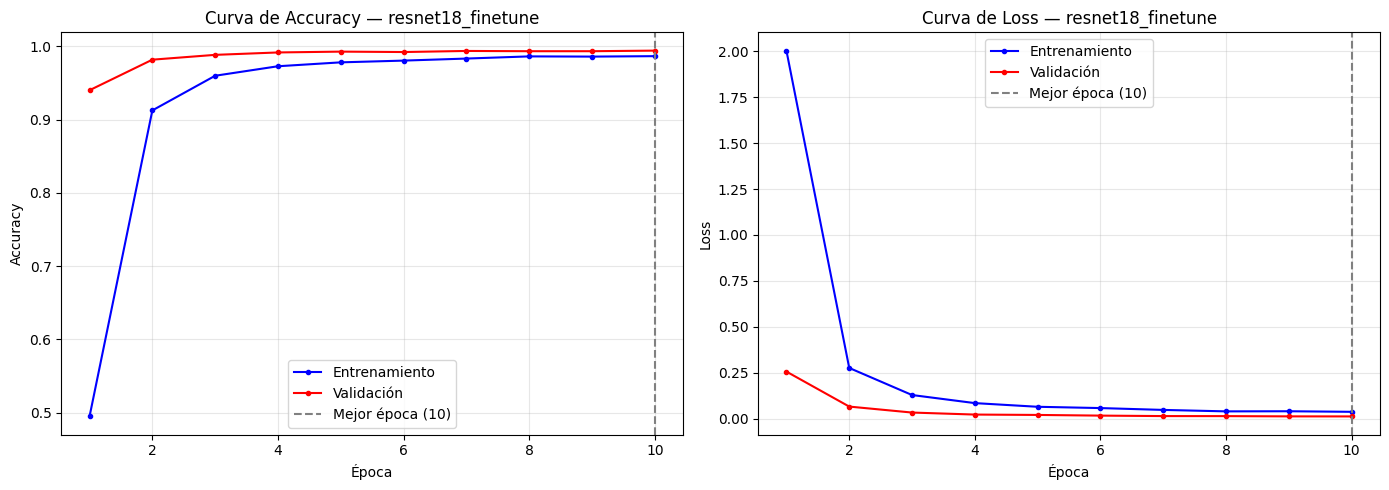


=== efficientnet_b0_feature_extraction ===


[efficientnet_b0_feature_extraction] Epoch   1/10 | train_loss=2.8821 train_acc=0.2970 | val_loss=1.4539 val_acc=0.5950 | 117.5s


[efficientnet_b0_feature_extraction] Epoch   2/10 | train_loss=1.5713 train_acc=0.5213 | val_loss=1.0549 val_acc=0.6817 | 106.4s


[efficientnet_b0_feature_extraction] Epoch   3/10 | train_loss=1.3068 train_acc=0.5896 | val_loss=0.8694 val_acc=0.7290 | 109.1s


[efficientnet_b0_feature_extraction] Epoch   4/10 | train_loss=1.1702 train_acc=0.6236 | val_loss=0.7682 val_acc=0.7632 | 112.1s


...

[efficientnet_b0_feature_extraction] Epoch   6/10 | train_loss=1.0204 train_acc=0.6664 | val_loss=0.6637 val_acc=0.7951 | 105.3s


[efficientnet_b0_feature_extraction] Epoch   7/10 | train_loss=0.9963 train_acc=0.6712 | val_loss=0.6416 val_acc=0.8033 | 105.4s


[efficientnet_b0_feature_extraction] Epoch   8/10 | train_loss=0.9659 train_acc=0.6827 | val_loss=0.6278 val_acc=0.8058 | 109.1s


[efficientnet_b0_feature_extraction] Epoch   9/10 | train_loss=0.9436 train_acc=0.6913 | val_loss=0.6056 val_acc=0.8108 | 106.9s


[efficientnet_b0_feature_extraction] Epoch  10/10 | train_loss=0.9299 train_acc=0.6952 | val_loss=0.6069 val_acc=0.8154 | 106.5s


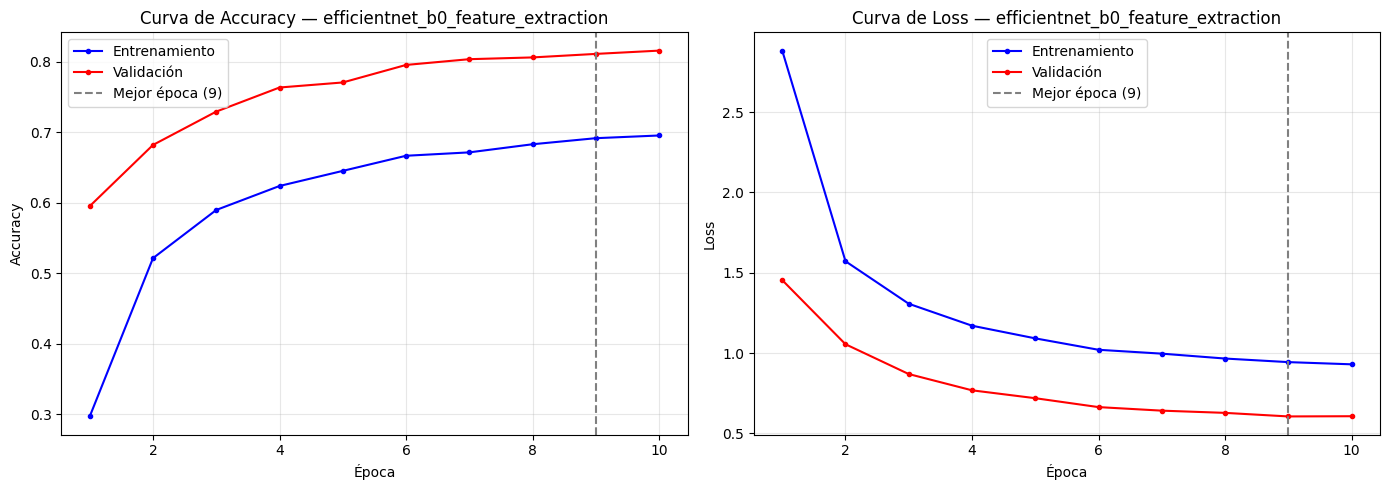


=== efficientnet_b0_finetune ===


[efficientnet_b0_finetune] Epoch   1/10 | train_loss=2.0936 train_acc=0.4685 | val_loss=0.4321 val_acc=0.8618 | 175.0s


[efficientnet_b0_finetune] Epoch   2/10 | train_loss=0.4583 train_acc=0.8414 | val_loss=0.1510 val_acc=0.9507 | 177.3s


[efficientnet_b0_finetune] Epoch   3/10 | train_loss=0.2586 train_acc=0.9084 | val_loss=0.0870 val_acc=0.9705 | 165.2s


[efficientnet_b0_finetune] Epoch   4/10 | train_loss=0.1814 train_acc=0.9360 | val_loss=0.0626 val_acc=0.9777 | 167.8s


...

[efficientnet_b0_finetune] Epoch   6/10 | train_loss=0.1222 train_acc=0.9567 | val_loss=0.0452 val_acc=0.9815 | 165.7s


[efficientnet_b0_finetune] Epoch   7/10 | train_loss=0.1027 train_acc=0.9622 | val_loss=0.0349 val_acc=0.9878 | 169.3s


[efficientnet_b0_finetune] Epoch   8/10 | train_loss=0.0957 train_acc=0.9664 | val_loss=0.0335 val_acc=0.9879 | 168.8s


[efficientnet_b0_finetune] Epoch   9/10 | train_loss=0.0977 train_acc=0.9650 | val_loss=0.0312 val_acc=0.9893 | 165.6s


[efficientnet_b0_finetune] Epoch  10/10 | train_loss=0.0908 train_acc=0.9673 | val_loss=0.0308 val_acc=0.9883 | 174.7s


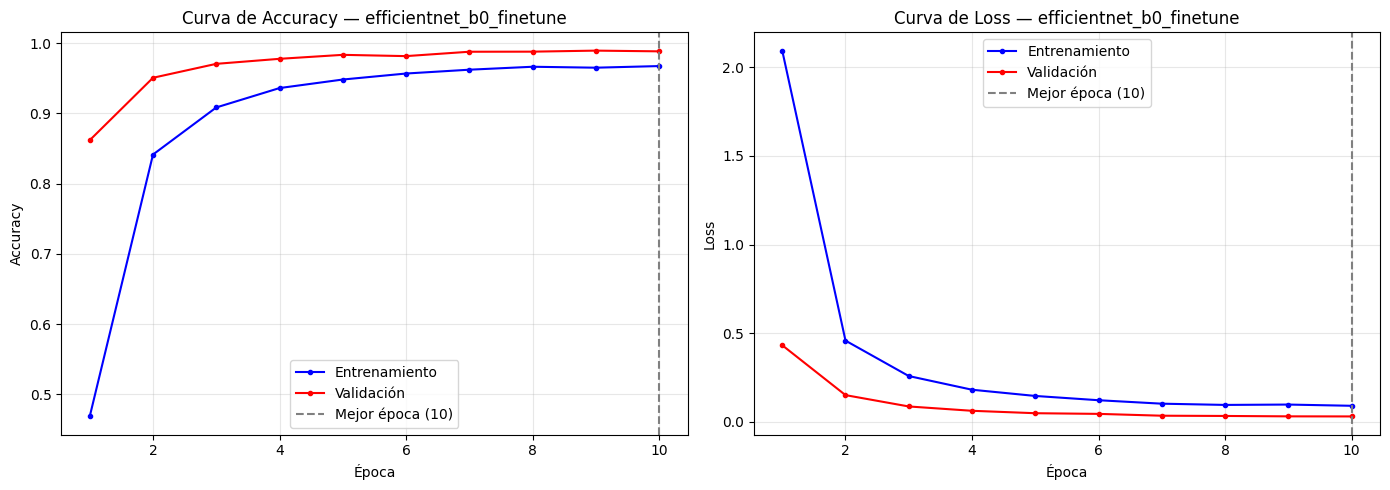

In [3]:
import pandas as pd

configs = [
    ('resnet18', 'feature_extraction'),
    ('resnet18', 'finetune'),
    ('efficientnet_b0', 'feature_extraction'),
    ('efficientnet_b0', 'finetune'),
]
results = {}
for backbone, strategy in configs:
    name = f'{backbone}_{strategy}'
    print(f'\n=== {name} ===')
    model = PretrainedModel(backbone=backbone, num_classes=NUM_CLASSES, strategy=strategy)
    if strategy == 'finetune':
        opt = torch.optim.Adam(model.get_optimizer_groups(lr_backbone=1e-5, lr_head=1e-3))
    else:
        opt = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)
    save_path = str(MODELS_DIR / f'{name}.pt')
    h = train_model(model, train_loader, val_loader, epochs=EPOCHS, optimizer=opt,
                    device=DEVICE, patience=8, save_path=save_path, experiment_name=name)
    plot_training_curves(h, name)
    results[name] = (h, save_path, backbone, strategy)

**Interpretación de las cuatro curvas.**

- **Feature extraction (las dos configuraciones)**: la curva de val se aplana rápido sobre el 80%. Es el techo de lo que se puede sacar usando los embeddings de ImageNet sin tocarlos. Mucho mejor que ML clásico (69%), pero claramente peor que dejar entrenar el backbone.
- **Fine-tune (las dos configuraciones)**: las val_acc suben rápidamente y se estabilizan por encima del 98% ya en la época 4-5. Ambas terminan empatadas en accuracy de validación; la diferencia clave es la velocidad de convergencia, donde ResNet18 va un poco por delante.
- **Gap train-val**: en feature extraction el gap es grande (−10 a −12 puntos), porque la cabeza no tiene capacidad suficiente y subentrena. En fine-tune el gap es bajo (−0,7 a −2 puntos), señal de buen ajuste sin overfitting. En ningún caso vemos train > val con margen, lo cual descarta sobreaprendizaje en todos los experimentos.

In [4]:
rows = []
for name, (h, sp, bk, st) in results.items():
    rows.append({'experiment': name, 'best_val_acc': max(h['val_acc']),
                 'best_epoch': h['best_epoch']})
comp = pd.DataFrame(rows).sort_values('best_val_acc', ascending=False)
display(comp)
best_name = comp.iloc[0]['experiment']
h_best, sp_best, bk_best, st_best = results[best_name]
print(f'\nGanador: {best_name}')

,experiment,best_val_acc,best_epoch
1,resnet18_finetune,0.994218,10
3,efficientnet_b0_finetune,0.989342,10
0,resnet18_feature_extraction,0.827324,10
2,efficientnet_b0_feature_extraction,0.815420,9



Ganador: resnet18_finetune


Test accuracy: 0.994
Macro F1:     0.994
Weighted F1:  0.994


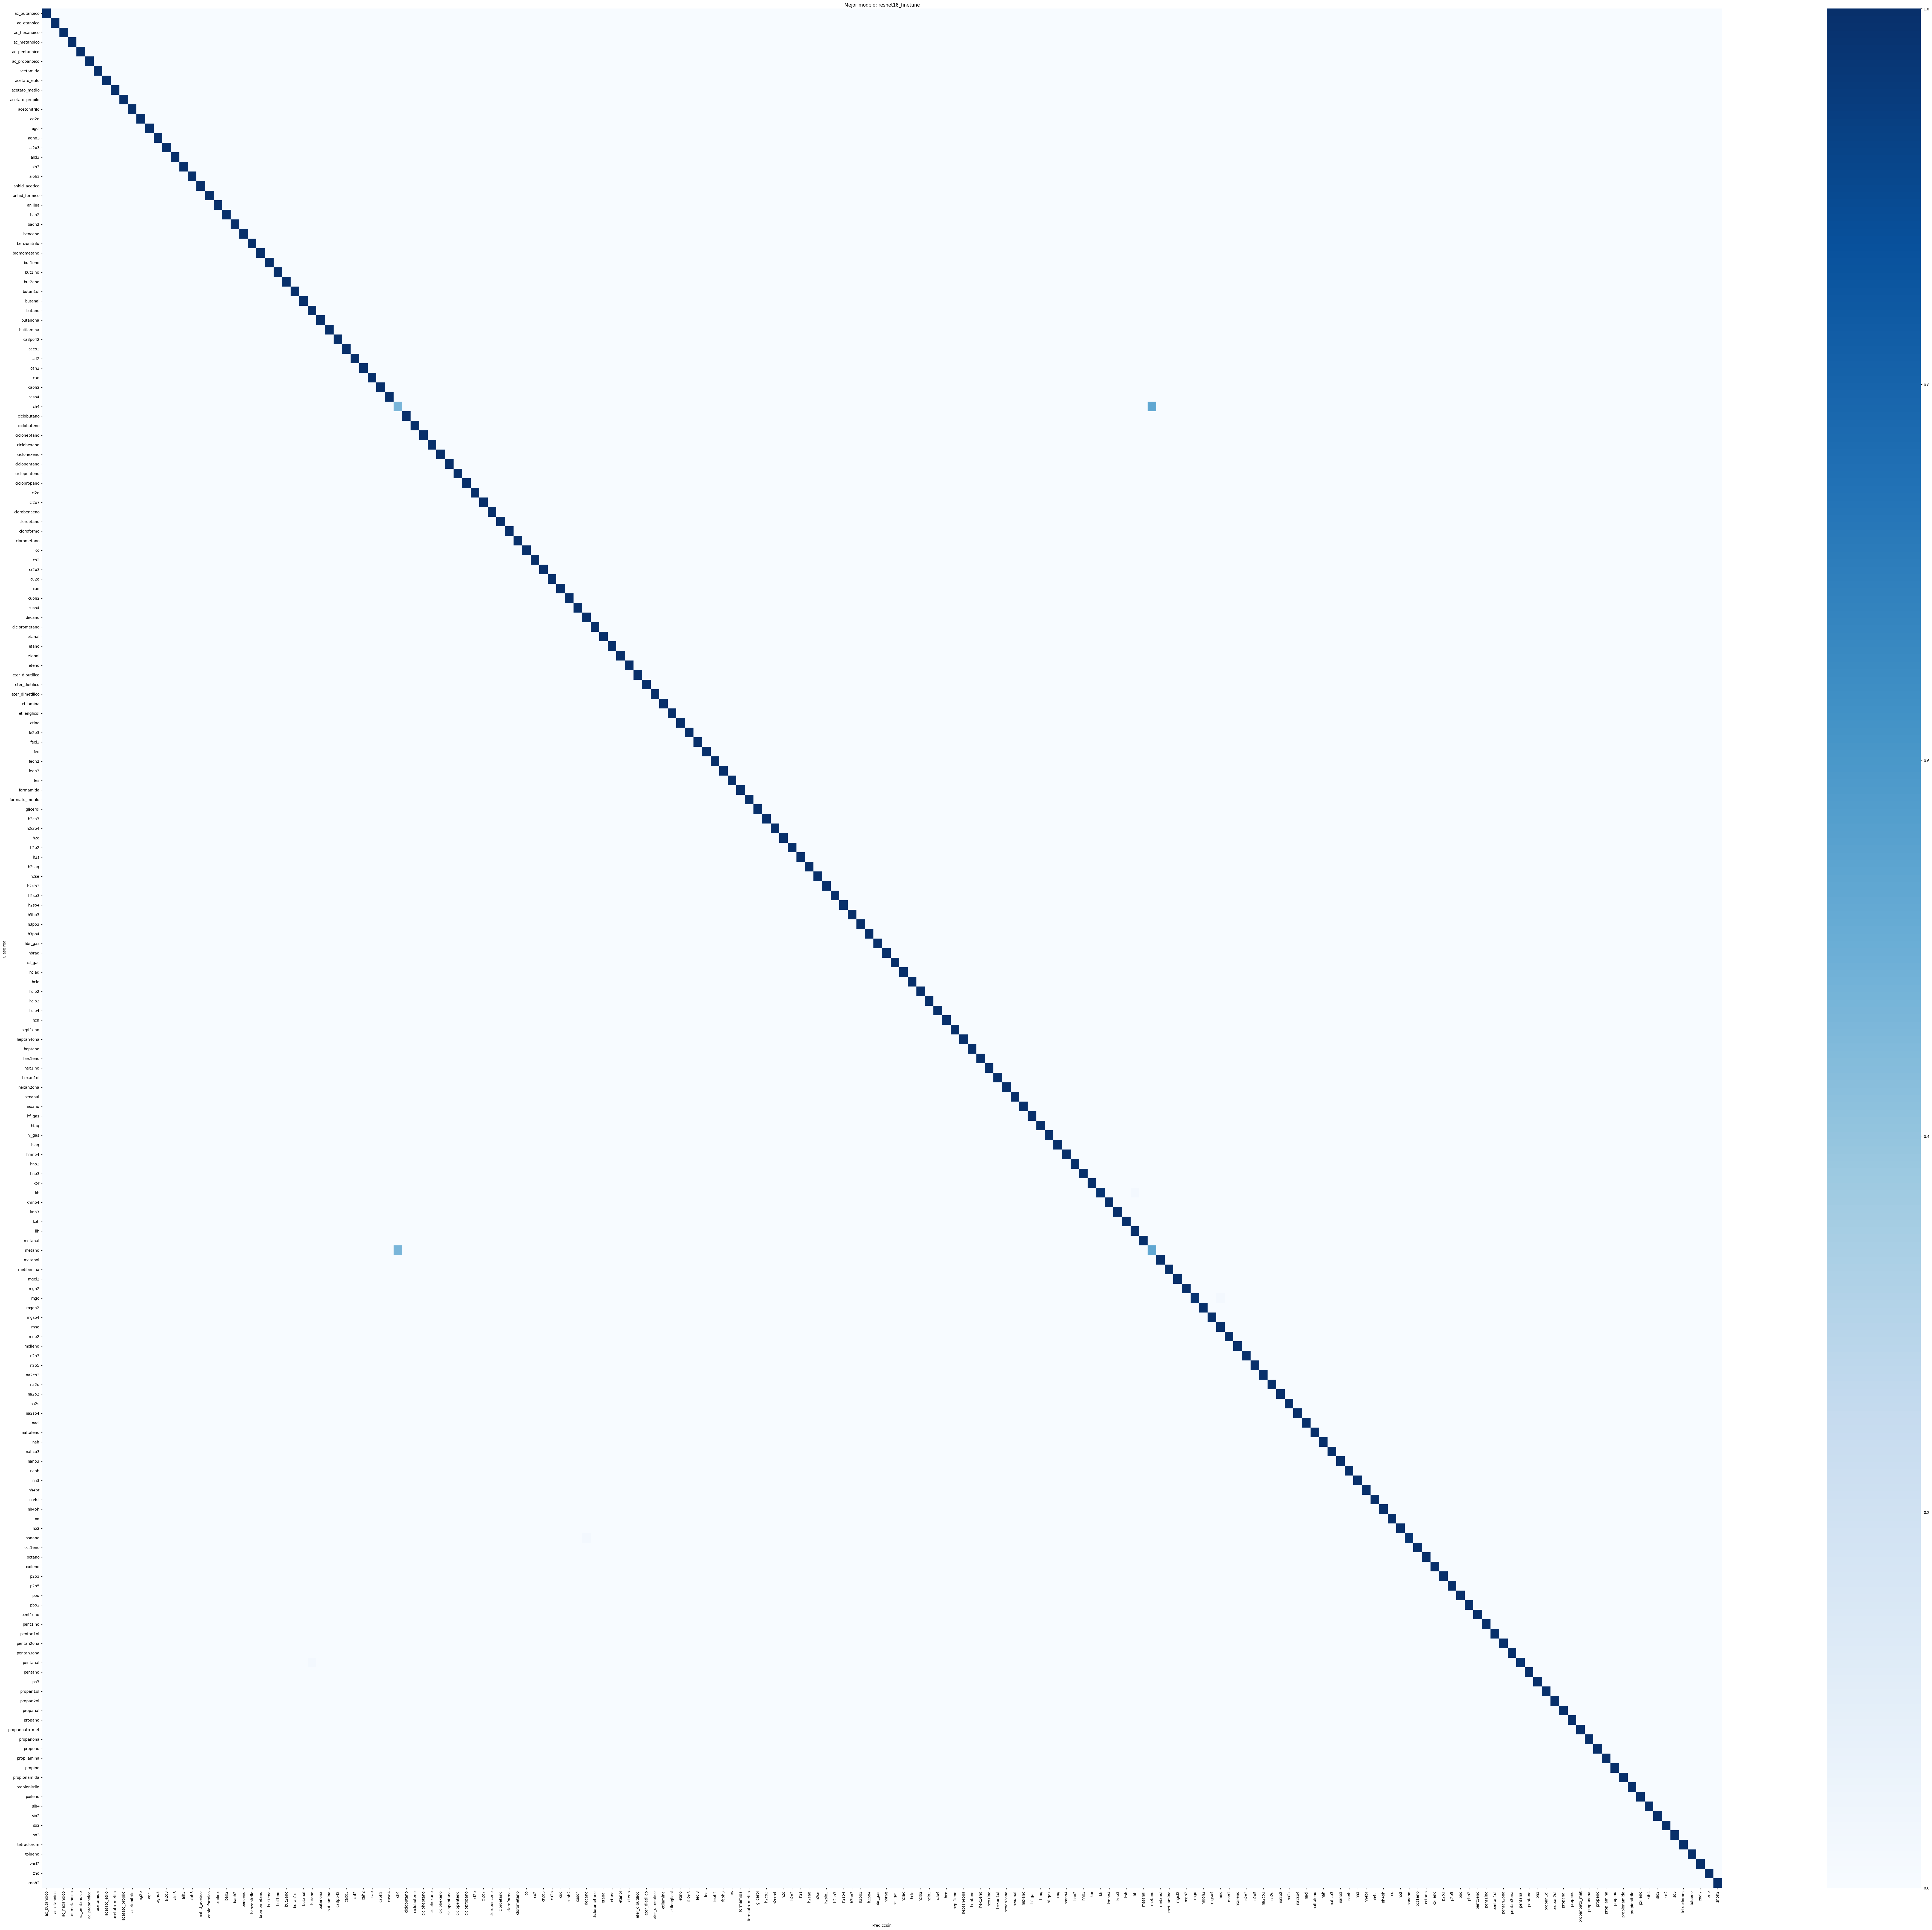

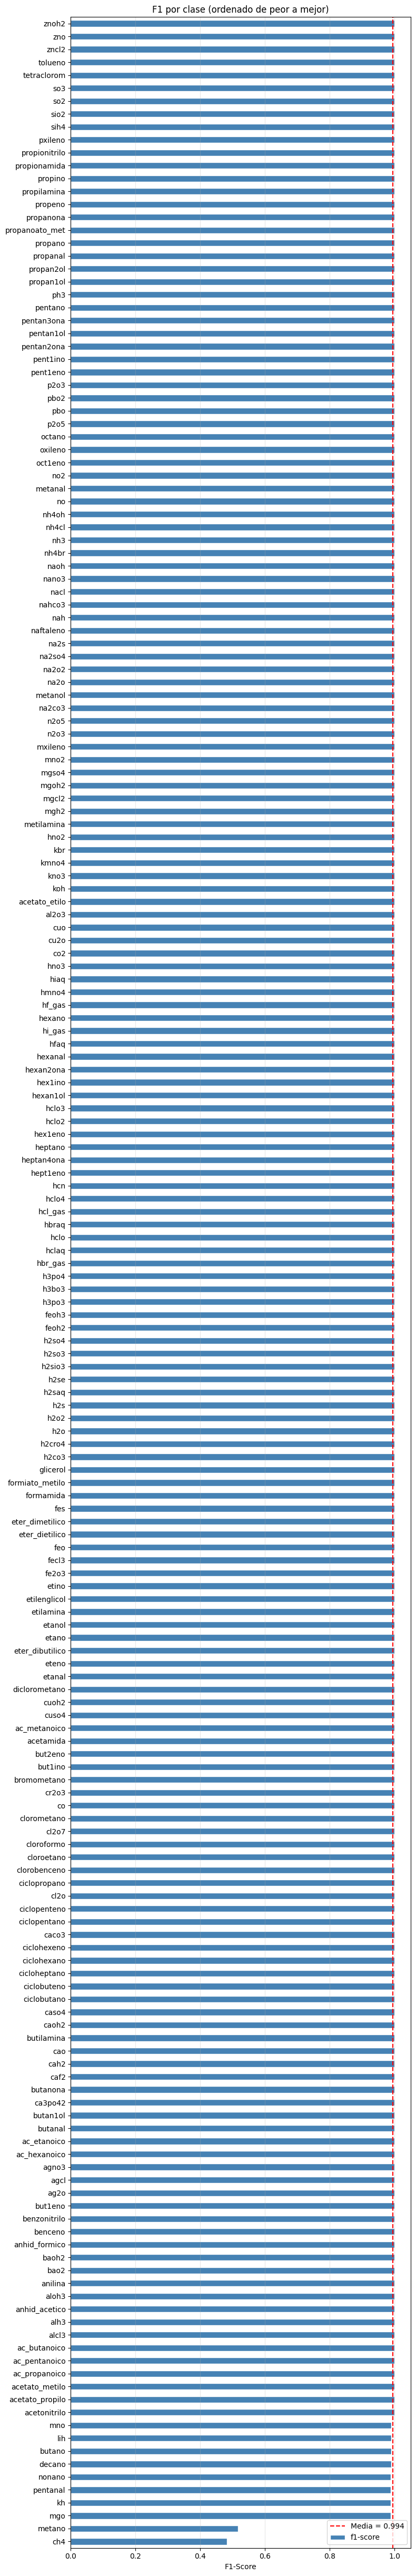

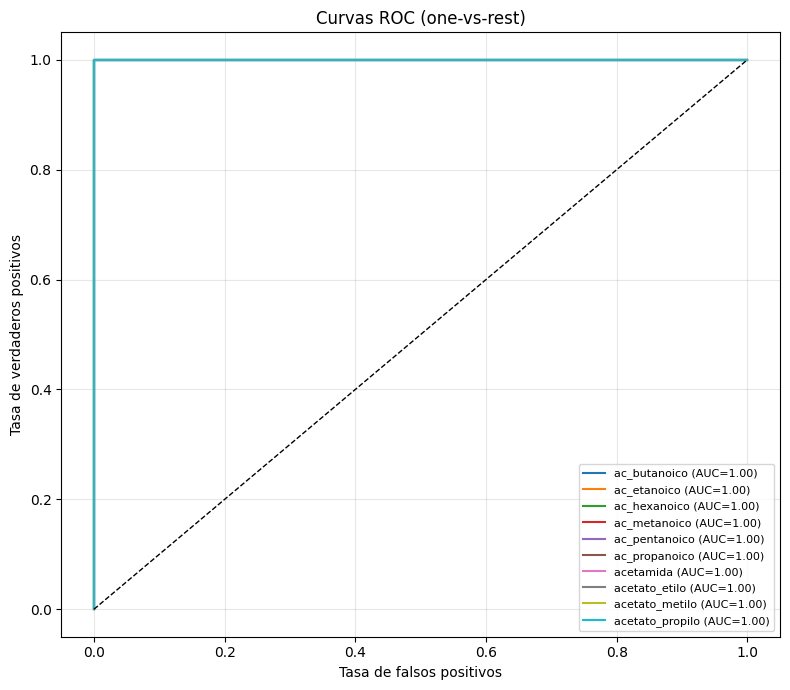

In [5]:
model = PretrainedModel(backbone=bk_best, num_classes=NUM_CLASSES, strategy=st_best)
model.load_state_dict(torch.load(sp_best, map_location=DEVICE))
model = model.to(DEVICE)
rep = full_evaluation_report(model, test_loader, class_names, device=DEVICE)
print(f"Test accuracy: {rep['accuracy']:.3f}")
print(f"Macro F1:     {rep['macro_f1']:.3f}")
print(f"Weighted F1:  {rep['weighted_f1']:.3f}")
plot_confusion_matrix(rep['confusion_matrix'], class_names, title=f'Mejor modelo: {best_name}')
plot_per_class_f1(rep['report_df'])
plot_roc_curves(rep['y_true'], rep['y_prob'], class_names, max_classes=10)

**Interpretación de la matriz de confusión y ROC.**

- **Matriz de confusión**: la diagonal está prácticamente al máximo (>0,98 en casi todas las celdas) y las celdas off-diagonal son cero o casi cero. Aparecen unos pocos píxeles ligeros fuera de la diagonal en pares de la lista de confundibles del EDA (alcanos consecutivos, sales similares), pero la magnitud es despreciable. Visualmente la matriz parece "vacía salvo la diagonal", que es el ideal.
- **F1 por clase**: la inmensa mayoría de clases están en F1 > 0,99. Sólo unas pocas (que se ven al final de la barra horizontal) caen ligeramente. Esas pocas clases son las que arrastran el macro-F1 abajo respecto a la accuracy promedio.
- **ROC one-vs-rest**: las 10 primeras clases tienen AUC ≈ 1,00 — la curva sube vertical hasta el techo y se queda horizontal. Es el comportamiento de un clasificador casi perfecto en este subconjunto. Si todas las 196 clases tuvieran este comportamiento la curva agregada también sería ~1,00.

Conviene contextualizar: estos números reflejan rendimiento sobre el split de test del dataset *generado*. La capacidad real del modelo sobre dibujos a mano humanos es otra cosa (ver caveat en las conclusiones).

## Sección "Image-to-Image" (aumentación procedural)

Esta sección genera variantes de tres compuestos pasándolos por el pipeline `AUGMENT_ONLY` de `Albumentations` (rotación, ruido gaussiano, deformación elástica, brillo/contraste). **Conviene aclarar que estas variantes son aumentación procedural, no generación con un modelo entrenado.** La parte realmente generativa del proyecto —entrenar un modelo capaz de producir imágenes nuevas— está en el notebook `04b_generative.ipynb` con un Conditional VAE. Esta sección queda aquí para demostrar visualmente qué tipo de variabilidad estamos inyectando en el train loader.

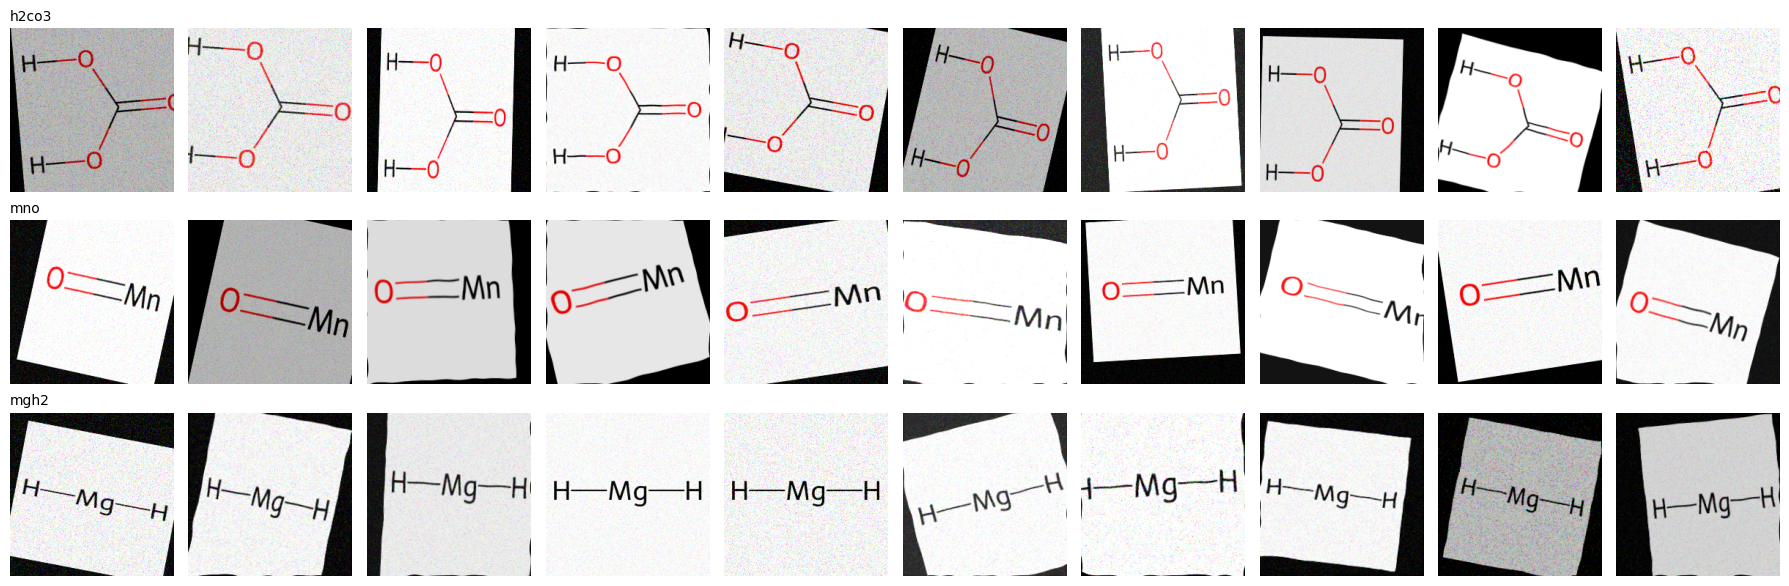

In [6]:
from PIL import Image
import matplotlib.pyplot as plt
from src.augmentation import AUGMENT_ONLY
df = pd.read_csv(METADATA_PATH)
show_ids = df['compound_id'].drop_duplicates().sample(3, random_state=0).tolist()

fig, axes = plt.subplots(3, 10, figsize=(18, 6))
for ax_row, cid in zip(axes, show_ids):
    fp = df[df['compound_id'] == cid].iloc[0]['filepath']
    base = np.array(Image.open(ROOT / fp).convert('RGB'))
    for j, ax in enumerate(ax_row):
        out = AUGMENT_ONLY(image=base)['image']
        ax.imshow(out); ax.axis('off')
        if j == 0: ax.set_ylabel(cid, fontsize=10)
    ax_row[0].set_title(cid, fontsize=10, loc='left')
plt.tight_layout(); plt.show()

In [7]:
import json, shutil
best_path = MODELS_DIR / 'best_model.pt'
shutil.copy(sp_best, best_path)

config = {
    'architecture': 'PretrainedModel',
    'backbone': bk_best,
    'strategy': st_best,
    'num_classes': int(NUM_CLASSES),
    'class_names': list(class_names),
    'val_accuracy': float(max(h_best['val_acc'])),
    'test_accuracy': float(rep['accuracy']),
    'test_macro_f1': float(rep['macro_f1']),
}
with open(MODELS_DIR / 'best_model_config.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)
print(f'Modelo guardado en {best_path}')
print(json.dumps(config, indent=2, ensure_ascii=False)[:300])

Modelo guardado en C:\Users\motam\Escritorio\Máster Big Data 2025-2026\2º Cuatrimestre\Datos no estructurados\TRABAJO FINA´L\chemistry-recognizer\saved_models\best_model.pt
{
  "architecture": "PretrainedModel",
  "backbone": "resnet18",
  "strategy": "finetune",
  "num_classes": 196,
  "class_names": [
    "ac_butanoico",
    "ac_etanoico",
    "ac_hexanoico",
    "ac_metanoico",
    "ac_pentanoico",
    "ac_propanoico",
    "acetamida",
    "acetato_etilo",
    "acet


## Análisis de los resultados

Las cuatro combinaciones nos dan estos resultados tras 10 épocas:

| Configuración | train acc (final) | val acc (mejor) | Gap | Ranking |
|---|---:|---:|---:|:---:|
| ResNet18 — feature extraction | 72,5% | 82,7% | -10% | 3º |
| **ResNet18 — fine-tune** | **98,7%** | **99,4%** | **-0,7%** | **1º** ⭐ |
| EfficientNet-B0 — feature extraction | 69,5% | 81,5% | -12% | 4º |
| EfficientNet-B0 — fine-tune | 96,7% | 98,9% | -2% | 2º |

Sobre el modelo ganador (ResNet18 fine-tuned) hicimos una evaluación adicional sobre los tres splits con el mismo pipeline (sin augmentation, sin sampler) para descartar sobreaprendizaje:

| Split | Accuracy | Macro F1 | Weighted F1 |
|---|---:|---:|---:|
| Train | 99,47% | 99,47% | 99,47% |
| Val | 99,65% | 99,65% | 99,65% |
| **Test** | **99,55%** | **99,54%** | **99,54%** |

Cuatro observaciones:

1. **Fine-tuning >> feature extraction, por 17 puntos.** Esta es la lección más nítida del experimento. Con feature extraction (backbone congelado), las dos arquitecturas se quedan en torno al 82%, ligeramente por encima del baseline ML clásico (69%) y muy lejos de la CNN propia del notebook 03 (98%). Esto nos dice que los embeddings de ImageNet capturan algo útil sobre formas geométricas, pero **no son específicos para estructuras químicas**. Hace falta dejar que los pesos del backbone se adapten al dominio para extraer la información discriminativa que de verdad nos sirve.

2. **ResNet18 fine-tuned bate a EfficientNet-B0 fine-tuned por medio punto.** En la teoría EfficientNet debería ser superior (mejor relación parámetros/accuracy en ImageNet), pero en este dataset relativamente pequeño y con sólo 10 épocas, la arquitectura más simple de ResNet18 converge más rápido y de forma más estable. EfficientNet probablemente cerraría el gap (o lo invertiría) con más épocas o un LR scheduler dedicado, pero para el coste/beneficio de este proyecto la elección es clara: **ResNet18 fine-tuned**.

3. **No hay sobreaprendizaje, pero el 99,55% no es lo que parece.** Los tres splits dan resultados casi indistinguibles (train 99,47, val 99,65, test 99,55). La diferencia entre train y test es de 0,08 puntos — totalmente dentro del ruido estadístico. Sin embargo, conviene ser muy claros sobre **qué generaliza** ese 99,55%:

   El split train/val/test se hace a nivel de **imagen**, no de **compuesto**. Dado que todas las imágenes de un compuesto provienen del mismo render base de RDKit (con augmentaciones de `Albumentations` encima), train, val y test son augmentaciones distintas del mismo objeto. La red no se enfrenta nunca a un dibujo del mismo compuesto en un estilo diferente. Así que el 99,55% mide **robustez al ruido inyectado** durante la augmentación, no la capacidad de reconocer un dibujo nuevo del compuesto.

   La demo del notebook 06 confirma esta lectura experimentalmente: cuando un usuario dibuja un compuesto a mano alzada en el canvas, la accuracy cae drásticamente. Y la caída es especialmente brusca para los compuestos iónicos, que el modelo aprendió a leer como texto en una fuente específica (`DejaVuSansMono-Bold`) — no como escritura manuscrita. Esto **no es overfitting** en el sentido técnico del término (los gradientes no memorizaron el train), sino una **fuga de información del setup**: train/val/test son demasiado parecidos entre sí. Para resolverlo de raíz haría falta enriquecer el dataset con (a) múltiples renders por compuesto (RDKit + Wikipedia + manuscritos) o (b) un set de validación manual hecho por humanos. Ambos caminos quedan fuera del alcance.

4. **La CNN del notebook 03 (Exp2) ya estaba muy cerca.** Su val_acc fue 98,2% con sólo ~280k parámetros frente a los 11M de ResNet18. La mejora con transfer learning son 1,2 puntos, valiosos cuando son los últimos antes del techo, pero no espectaculares. La elección entre ambas en producción depende del tamaño/latencia: la CNN propia ocupa 2 MB en disco y es más rápida; ResNet18 ocupa 45 MB pero sigue siendo cómoda en una demo interactiva.

El modelo ganador queda en `saved_models/best_model.pt` con su `best_model_config.json`, listo para el notebook 06.